In [ ]:
from pathlib import Path
import pandas as pd

# Dataset Paths

PARASITIZED_DIR = Path(
    r"C:\Users\USER\Desktop\D\cell_images\cell_images\Parasitized"
)

UNINFECTED_DIR = Path(
    r"C:\Users\USER\Desktop\D\cell_images\cell_images\Uninfected"
)


# Valid Image Extensions


VALID_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff"
}


# Function to Load Images


def get_image_files(folder):
    return sorted([
        file for file in folder.iterdir()
        if file.is_file() and file.suffix.lower() in VALID_EXTENSIONS
    ])


# Read Image Paths


parasitized_images = get_image_files(PARASITIZED_DIR)
uninfected_images = get_image_files(UNINFECTED_DIR)


# Count Images


num_parasitized = len(parasitized_images)
num_uninfected = len(uninfected_images)
total_images = num_parasitized + num_uninfected

print("Malaria Dataset Summary")
print(f"Parasitized Images : {num_parasitized}")
print(f"Uninfected Images  : {num_uninfected}")
print(f"Total Images       : {total_images}")


# Create DataFrame


image_paths = parasitized_images + uninfected_images

labels = (
    ["Parasitized"] * num_parasitized +
    ["Uninfected"] * num_uninfected
)

dataset = pd.DataFrame({
    "image_path": [str(path) for path in image_paths],
    "label": labels
})

print("\nFirst Five Samples:")
print(dataset.head())

print("\nDataset Shape:")
print(dataset.shape)

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import random

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

# Random Parasitized Image
p_img = random.choice(parasitized_images)
axes[0].imshow(Image.open(p_img))
axes[0].set_title("Parasitized")
axes[0].axis("off")

# Random Uninfected Image
u_img = random.choice(uninfected_images)
axes[1].imshow(Image.open(u_img))
axes[1].set_title("Uninfected")
axes[1].axis("off")

plt.tight_layout()
plt.show()

: 

In [5]:
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd

# Analyze Image Dimensions


widths = []
heights = []

# Combine both classes
all_images = parasitized_images + uninfected_images

for img_path in all_images:
    try:
        with Image.open(img_path) as img:
            width, height = img.size
            widths.append(width)
            heights.append(height)
    except Exception as e:
        print(f"Error reading {img_path}: {e}")

# Create DataFrame


dimension_df = pd.DataFrame({
    "Width": widths,
    "Height": heights
})

print("="*50)
print("Image Dimension Statistics")
print("="*50)
print(dimension_df.describe())

print("\nMinimum Width :", dimension_df["Width"].min())
print("Maximum Width :", dimension_df["Width"].max())
print("Minimum Height:", dimension_df["Height"].min())
print("Maximum Height:", dimension_df["Height"].max())

# Check Whether Scaling is Needed

unique_sizes = dimension_df.drop_duplicates()

print("Number of Unique Image Sizes:", len(unique_sizes))

if len(unique_sizes) == 1:
    print("All images have identical dimensions.")
    print("Scaling is NOT mandatory (unless required by the model).")
else:
    print("Images have varying dimensions.")
    print("Image resizing/scaling is REQUIRED before training.")

Image Dimension Statistics
              Width        Height
count  27558.000000  27558.000000
mean     132.763082    133.259489
std       20.635278     21.203494
min       46.000000     40.000000
25%      121.000000    121.000000
50%      130.000000    130.000000
75%      142.000000    145.000000
max      394.000000    385.000000

Minimum Width : 46
Maximum Width : 394
Minimum Height: 40
Maximum Height: 385
Number of Unique Image Sizes: 1627
Images have varying dimensions.
Image resizing/scaling is REQUIRED before training.


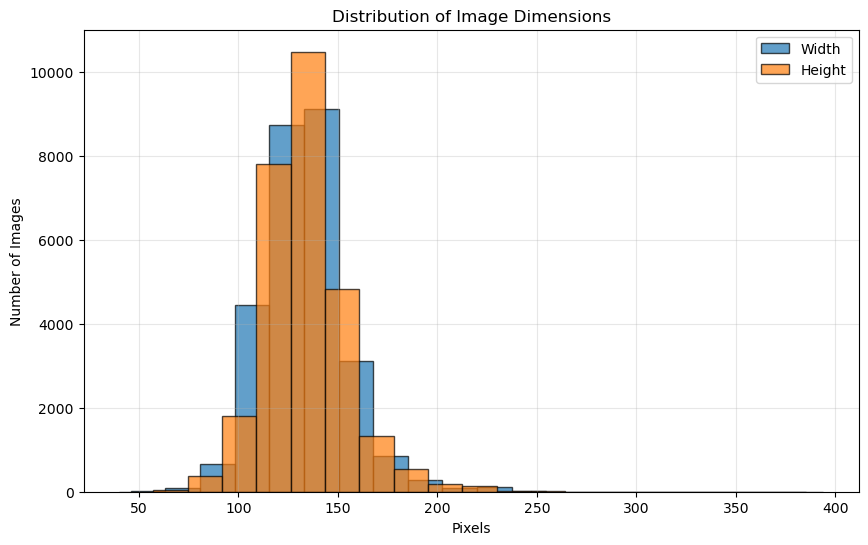

In [6]:
# Histogram of Image Width and Height

plt.figure(figsize=(10,6))

plt.hist(widths,
         bins=20,
         alpha=0.7,
         label='Width',
         edgecolor='black')

plt.hist(heights,
         bins=20,
         alpha=0.7,
         label='Height',
         edgecolor='black')

plt.title("Distribution of Image Dimensions")
plt.xlabel("Pixels")
plt.ylabel("Number of Images")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [7]:
import tensorflow as tf

IMG_SIZE = (224, 224)

AUTOTUNE = tf.data.AUTOTUNE

def load_and_preprocess(image_path, label):
    # Read image
    image = tf.io.read_file(image_path)

    # Decode image
    image = tf.image.decode_jpeg(image, channels=3)

    # Resize
    image = tf.image.resize(image, IMG_SIZE)

    # Normalize pixel values to [0,1]
    image = image / 255.0

    return image, label

In [8]:
dataset["label"] = dataset["label"].map({
    "Parasitized": 1,
    "Uninfected": 0
})

In [9]:
image_paths = dataset["image_path"].values
labels = dataset["label"].values

tf_dataset = tf.data.Dataset.from_tensor_slices((image_paths, labels))

tf_dataset = tf_dataset.map(
    load_and_preprocess,
    num_parallel_calls=AUTOTUNE
)

tf_dataset = tf_dataset.batch(32).prefetch(AUTOTUNE)

In [10]:
for images, labels in tf_dataset.take(1):
    print("Image Batch Shape :", images.shape)
    print("Label Batch Shape :", labels.shape)

Image Batch Shape : (32, 224, 224, 3)
Label Batch Shape : (32,)


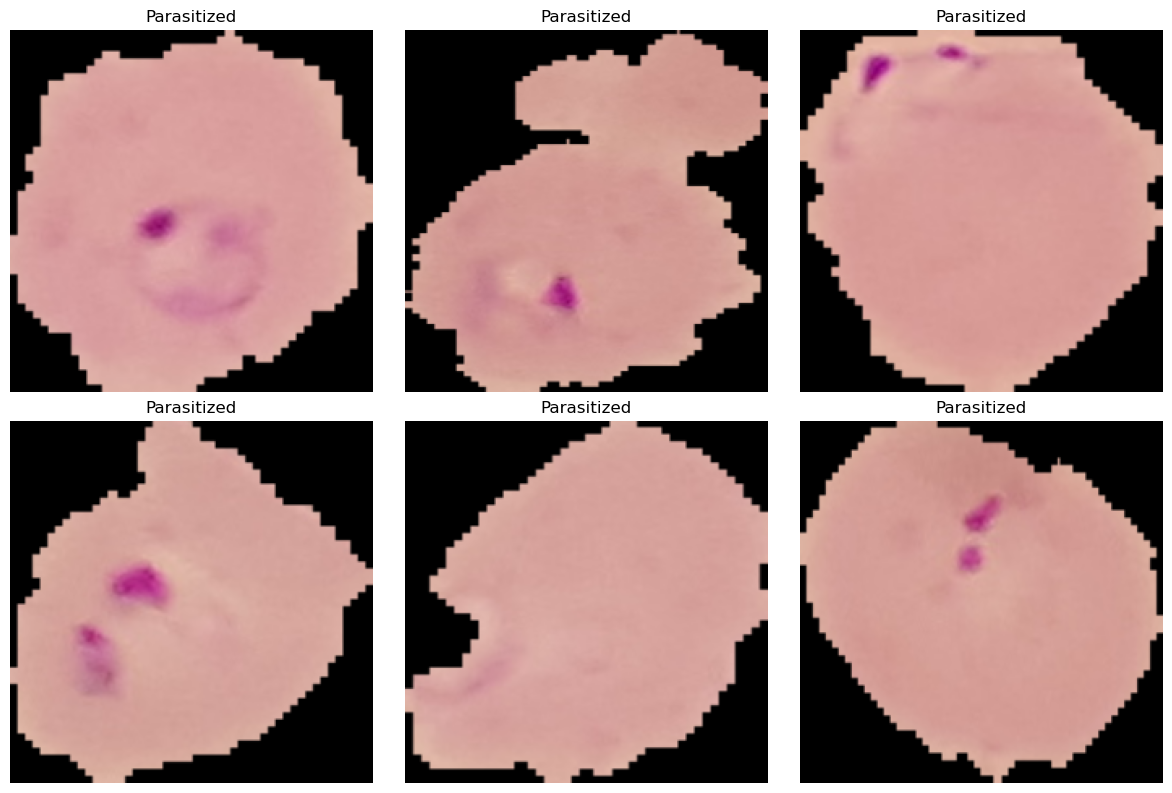

In [11]:
import matplotlib.pyplot as plt

# Take one batch
for images, labels in tf_dataset.take(1):

    plt.figure(figsize=(12, 8))

    for i in range(6):
        plt.subplot(2, 3, i + 1)

        plt.imshow(images[i].numpy())

        plt.title("Parasitized" if labels[i] == 1 else "Uninfected")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

In [12]:
for images, labels in tf_dataset.take(1):
    print("First image shape:", images[0].shape)

First image shape: (224, 224, 3)


In [13]:
global_min = 1.0
global_max = 0.0

for images, labels in tf_dataset:
    batch_min = tf.reduce_min(images).numpy()
    batch_max = tf.reduce_max(images).numpy()

    global_min = min(global_min, batch_min)
    global_max = max(global_max, batch_max)

print("Global Minimum:", global_min)
print("Global Maximum:", global_max)

Global Minimum: 0.0
Global Maximum: 1.0


In [14]:
print(dataset.head())

print("\nUnique Labels:")
print(dataset["label"].unique())

print("\nLabel Counts:")
print(dataset["label"].value_counts())

                                          image_path  label
0  C:\Users\Swarnava\Desktop\cell_images\cell_ima...      1
1  C:\Users\Swarnava\Desktop\cell_images\cell_ima...      1
2  C:\Users\Swarnava\Desktop\cell_images\cell_ima...      1
3  C:\Users\Swarnava\Desktop\cell_images\cell_ima...      1
4  C:\Users\Swarnava\Desktop\cell_images\cell_ima...      1

Unique Labels:
[1 0]

Label Counts:
label
1    13779
0    13779
Name: count, dtype: int64


In [15]:
from sklearn.model_selection import train_test_split

# Image Paths and Labels

X = dataset["image_path"].values
y = dataset["label"].values

# First Split: Train (70%) and Temp (30%)

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y,
    shuffle=True
)

# Second Split: Validation (15%) and Test (15%)


X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp,
    shuffle=True
)

# Print Dataset Sizes


print("Dataset Split")


print(f"Training Images   : {len(X_train)}")
print(f"Validation Images : {len(X_val)}")
print(f"Testing Images    : {len(X_test)}")

print("\nClass Distribution")

print("\nTraining")
print(pd.Series(y_train).value_counts())

print("\nValidation")
print(pd.Series(y_val).value_counts())

print("\nTesting")
print(pd.Series(y_test).value_counts())

Dataset Split
Training Images   : 19290
Validation Images : 4134
Testing Images    : 4134

Class Distribution

Training
1    9645
0    9645
Name: count, dtype: int64

Validation
0    2067
1    2067
Name: count, dtype: int64

Testing
0    2067
1    2067
Name: count, dtype: int64


In [16]:
# Create TensorFlow Datasets
import tensorflow as tf

IMG_SIZE = (224,224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE


def load_and_preprocess(image_path, label):

    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)

    image = tf.image.resize(image, IMG_SIZE)

    image = image / 255.0

    return image, label


# Training Dataset
train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_ds = train_ds.map(load_and_preprocess,
                        num_parallel_calls=AUTOTUNE)

# Validation Dataset
val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val))
val_ds = val_ds.map(load_and_preprocess,
                    num_parallel_calls=AUTOTUNE)

# Testing Dataset
test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test))
test_ds = test_ds.map(load_and_preprocess,
                      num_parallel_calls=AUTOTUNE)

In [17]:
# Data Augmentation
from tensorflow.keras import Sequential
from tensorflow.keras.layers import RandomFlip
from tensorflow.keras.layers import RandomRotation
from tensorflow.keras.layers import RandomZoom
from tensorflow.keras.layers import RandomContrast

data_augmentation = Sequential([

    RandomFlip("horizontal"),

    RandomRotation(0.10),

    RandomZoom(0.10),

    RandomContrast(0.10)

], name="Data_Augmentation")

train_ds = train_ds.map(
    lambda x, y: (data_augmentation(x, training=True), y),
    num_parallel_calls=AUTOTUNE
)

train_ds = train_ds.shuffle(1000)\
                   .batch(BATCH_SIZE)\
                   .prefetch(AUTOTUNE)

val_ds = val_ds.batch(BATCH_SIZE)\
               .prefetch(AUTOTUNE)

test_ds = test_ds.batch(BATCH_SIZE)\
                 .prefetch(AUTOTUNE)

for images, labels in train_ds.take(1):

    print("Images :", images.shape)
    print("Labels :", labels.shape)

Images : (32, 224, 224, 3)
Labels : (32,)


CNN model summary


D:\Anaconda\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 24, 24, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 512)            │    18,874,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,396,801 (73.99 MB)

 Trainable params: 19,395,841 (73.99 MB)

 Non-trainable params: 960 (3.75 KB)

Training CNN Model
Epoch 1/5
603/603 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7324 - loss: 2.1974
Epoch 1: val_accuracy improved from None to 0.50919, saving model to CNN_model.keras

Epoch 1: finished saving model to CNN_model.keras
603/603 ━━━━━━━━━━━━━━━━━━━━ 1226s 2s/step - accuracy: 0.7987 - loss: 1.1651 - val_accuracy: 0.5092 - val_loss: 1.6084 - learning_rate: 0.0010
Epoch 2/5
603/603 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8906 - loss: 0.3639
Epoch 2: val_accuracy improved from 0.50919 to 0.89623, saving model to CNN_model.keras

Epoch 2: finished saving model to CNN_model.keras
603/603 ━━━━━━━━━━━━━━━━━━━━ 1190s 2s/step - accuracy: 0.9044 - loss: 0.3244 - val_accuracy: 0.8962 - val_loss: 0.2842 - learning_rate: 0.0010
Epoch 3/5
603/603 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9275 - loss: 0.2607
Epoch 3: val_accuracy did not improve from 0.89623
603/603 ━━━━━━━━━━━━━━━━━━━━ 1162s 2s/step - accuracy: 0.9331 - loss: 0.2326 - val_accuracy: 0.7995 - val_loss: 0.442

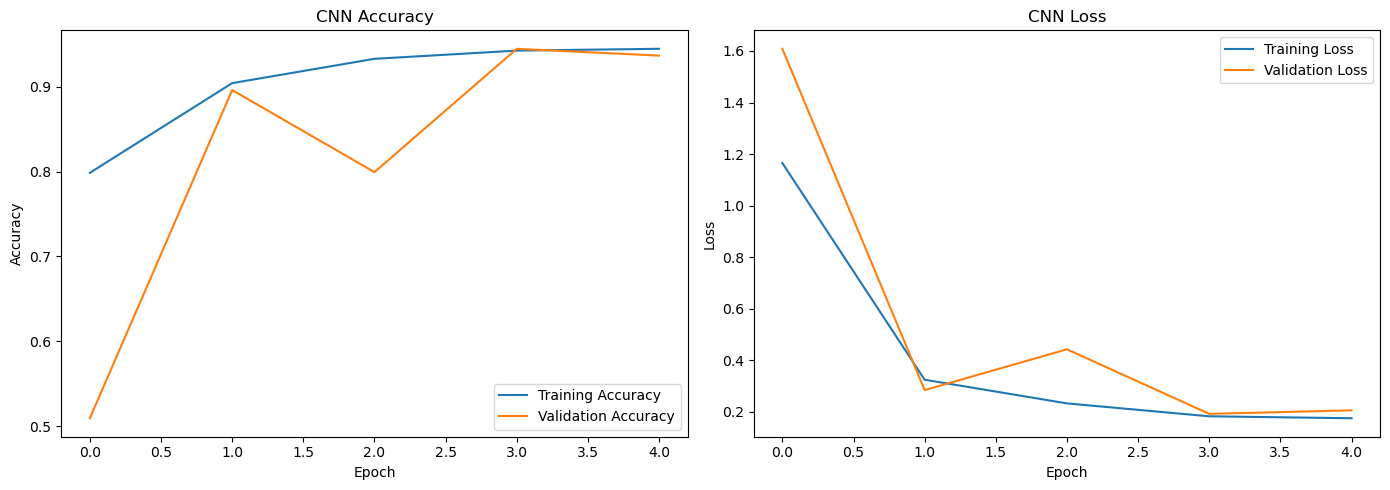

130/130 ━━━━━━━━━━━━━━━━━━━━ 53s 405ms/step
CNN performance
Accuracy      : 94.90%
Precision     : 94.79%
Recall        : 95.02%
F1 Score      : 94.90%

Training Time : 5992.20 seconds
Testing Time  : 52.91 seconds
Classification report
              precision    recall  f1-score   support

  Uninfected       0.95      0.95      0.95      2067
 Parasitized       0.95      0.95      0.95      2067

    accuracy                           0.95      4134
   macro avg       0.95      0.95      0.95      4134
weighted avg       0.95      0.95      0.95      4134



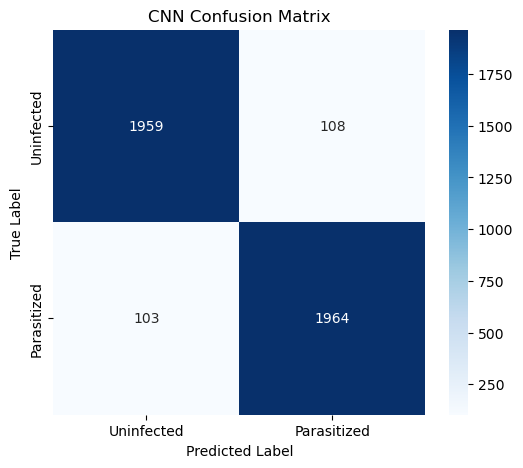

CNN Model Saved Successfully!


In [ ]:
# CNN Model for Malaria Cell Classification

import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization
)
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

# Build CNN Model


cnn_model = Sequential([

    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Conv2D(256, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Flatten(),

    Dense(512, activation='relu'),
    Dropout(0.5),

    Dense(256, activation='relu'),
    Dropout(0.3),

    Dense(1, activation='sigmoid')

])

# Display Model Summary

print("CNN model summary")


cnn_model.summary()

# Compile Model


cnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Callbacks

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "CNN_model.keras",
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    verbose=1
)

# Train Model


print("Training CNN Model")

start_train = time.time()

cnn_history = cnn_model.fit(

    train_ds,

    validation_data=val_ds,

    epochs=5,

    callbacks=[
        early_stop,
        checkpoint,
        reduce_lr
    ]

)

end_train = time.time()

cnn_training_time = end_train - start_train

print(f"\nTraining Time : {cnn_training_time:.2f} seconds")

# Plot Accuracy & Loss


plt.figure(figsize=(14,5))

plt.subplot(1,2,1)

plt.plot(cnn_history.history['accuracy'], label='Training Accuracy')
plt.plot(cnn_history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Accuracy")
plt.legend()

plt.subplot(1,2,2)

plt.plot(cnn_history.history['loss'], label='Training Loss')
plt.plot(cnn_history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Loss")
plt.legend()

plt.tight_layout()
plt.show()

# Evaluate Model

start_test = time.time()

predictions = cnn_model.predict(test_ds)

end_test = time.time()

cnn_testing_time = end_test - start_test

y_pred_cnn = (predictions > 0.5).astype(int).flatten()

# True Labels

y_true = np.concatenate([

    labels.numpy()

    for images, labels in test_ds

])

# Performance Metrics

accuracy_cnn = accuracy_score(y_true, y_pred_cnn)

precision_cnn = precision_score(y_true, y_pred_cnn)

recall_cnn = recall_score(y_true, y_pred_cnn)

f1_cnn = f1_score(y_true, y_pred_cnn)


print("CNN performance")


print(f"Accuracy      : {accuracy_cnn*100:.2f}%")
print(f"Precision     : {precision_cnn*100:.2f}%")
print(f"Recall        : {recall_cnn*100:.2f}%")
print(f"F1 Score      : {f1_cnn*100:.2f}%")

print(f"\nTraining Time : {cnn_training_time:.2f} seconds")

print(f"Testing Time  : {cnn_testing_time:.2f} seconds")


# Classification Report


print("Classification report")


print(

    classification_report(

        y_true,

        y_pred_cnn,

        target_names=[

            "Uninfected",

            "Parasitized"

        ]

    )

)


# Confusion Matrix

cm = confusion_matrix(y_true, y_pred_cnn)

plt.figure(figsize=(6,5))

sns.heatmap(

    cm,

    annot=True,

    fmt='d',

    cmap='Blues',

    xticklabels=[

        "Uninfected",

        "Parasitized"

    ],

    yticklabels=[

        "Uninfected",

        "Parasitized"

    ]

)

plt.xlabel("Predicted Label")

plt.ylabel("True Label")

plt.title("CNN Confusion Matrix")

plt.show()

# Save Final Model


cnn_model.save("CNN_model.keras")

print("CNN Model Saved Successfully!")

# Store Results for Final Comparison


cnn_results = {

    "Model": "CNN",

    "Accuracy": accuracy_cnn,

    "Precision": precision_cnn,

    "Recall": recall_cnn,

    "F1 Score": f1_cnn,

    "Training Time": cnn_training_time,

    "Testing Time": cnn_testing_time

}

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 18s 0us/step
VGG16 Model Summary



Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 15,108,929 (57.64 MB)

 Trainable params: 394,241 (1.50 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

Training VGG16 Model...

Epoch 1/5
603/603 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.6948 - loss: 0.5513
Epoch 1: val_accuracy improved from None to 0.89574, saving model to VGG16_model.keras

Epoch 1: finished saving model to VGG16_model.keras
603/603 ━━━━━━━━━━━━━━━━━━━━ 3123s 5s/step - accuracy: 0.7907 - loss: 0.4294 - val_accuracy: 0.8957 - val_loss: 0.2894 - learning_rate: 0.0010
Epoch 2/5
603/603 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.8641 - loss: 0.3250
Epoch 2: val_accuracy improved from 0.89574 to 0.90203, saving model to VGG16_model.keras

Epoch 2: finished saving model to VGG16_model.keras
603/603 ━━━━━━━━━━━━━━━━━━━━ 2990s 5s/step - accuracy: 0.8698 - loss: 0.3137 - val_accuracy: 0.9020 - val_loss: 0.2580 - learning_rate: 0.0010
Epoch 3/5
603/603 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.8708 - loss: 0.3104
Epoch 3: val_accuracy improved from 0.90203 to 0.90493, saving model to VGG16_model.keras

Epoch 3: finished saving model to VGG16_model.keras
603/603 ━━━

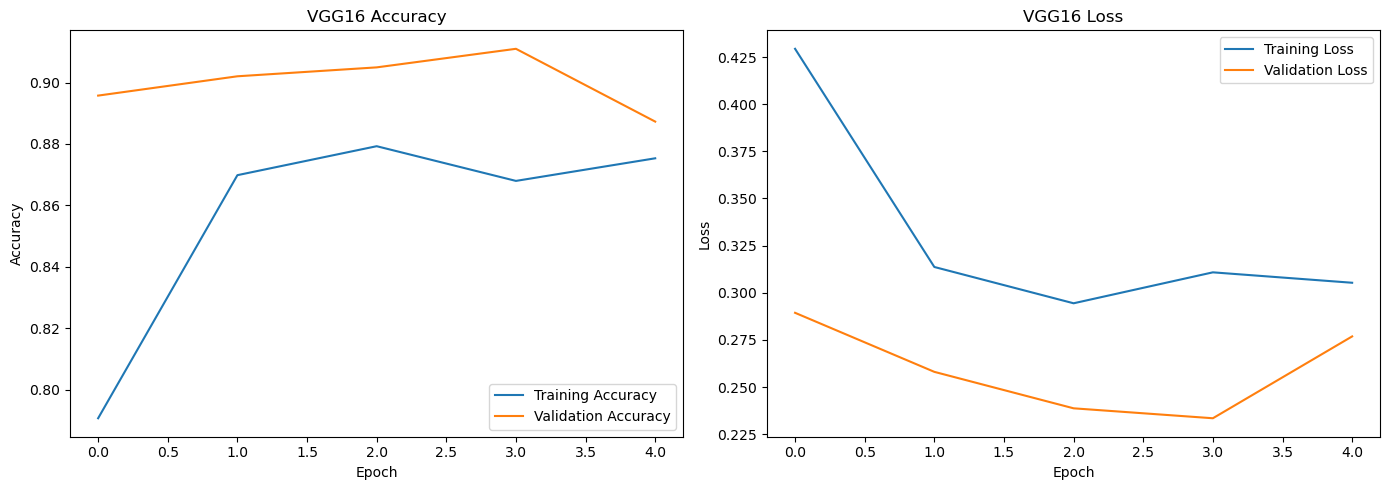

130/130 ━━━━━━━━━━━━━━━━━━━━ 499s 4s/step

VGG16 Performance

Accuracy      : 91.17%
Precision     : 92.64%
Recall        : 89.45%
F1 Score      : 91.02%

Training Time : 14757.13 seconds
Testing Time  : 499.53 seconds
              precision    recall  f1-score   support

  Uninfected       0.90      0.93      0.91      2067
 Parasitized       0.93      0.89      0.91      2067

    accuracy                           0.91      4134
   macro avg       0.91      0.91      0.91      4134
weighted avg       0.91      0.91      0.91      4134



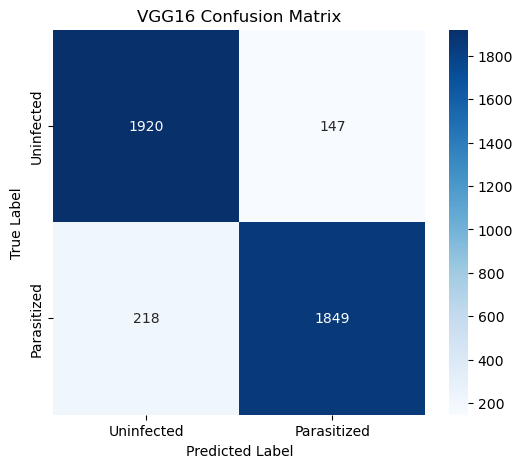

VGG16 Model Saved Successfully!


In [ ]:
#VGG16

import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

import tensorflow as tf

from tensorflow.keras.applications import VGG16

from tensorflow.keras.models import Model

from tensorflow.keras.layers import (
    GlobalAveragePooling2D,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

# Load VGG16 Base Model

base_model = VGG16(

    weights="imagenet",

    include_top=False,

    input_shape=(224,224,3)

)

base_model.trainable = False

# Build VGG16 Model

x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dense(512, activation="relu")(x)

x = Dropout(0.5)(x)

x = Dense(256, activation="relu")(x)

x = Dropout(0.3)(x)

output = Dense(1, activation="sigmoid")(x)

vgg16_model = Model(

    inputs=base_model.input,

    outputs=output

)

# Display Model Summary

print("VGG16 Model Summary\n")

vgg16_model.summary()

# Compile Model

vgg16_model.compile(

    optimizer="adam",

    loss="binary_crossentropy",

    metrics=["accuracy"]

)

# Callbacks

early_stop = EarlyStopping(

    monitor="val_loss",

    patience=5,

    restore_best_weights=True

)

checkpoint = ModelCheckpoint(

    "VGG16_model.keras",

    monitor="val_accuracy",

    save_best_only=True,

    verbose=1

)

reduce_lr = ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.2,

    patience=3,

    verbose=1

)

# Train Model

print("Training VGG16 Model...\n")

start_train = time.time()

vgg16_history = vgg16_model.fit(

    train_ds,

    validation_data=val_ds,

    epochs=5,

    callbacks=[

        early_stop,

        checkpoint,

        reduce_lr

    ]

)

end_train = time.time()

vgg16_training_time = end_train - start_train

print(f"\nTraining Time : {vgg16_training_time:.2f} seconds")

# Plot Accuracy and Loss

plt.figure(figsize=(14,5))

plt.subplot(1,2,1)

plt.plot(

    vgg16_history.history["accuracy"],

    label="Training Accuracy"

)

plt.plot(

    vgg16_history.history["val_accuracy"],

    label="Validation Accuracy"

)

plt.title("VGG16 Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.subplot(1,2,2)

plt.plot(

    vgg16_history.history["loss"],

    label="Training Loss"

)

plt.plot(

    vgg16_history.history["val_loss"],

    label="Validation Loss"

)

plt.title("VGG16 Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.tight_layout()

plt.show()

# Evaluate Model

start_test = time.time()

predictions = vgg16_model.predict(test_ds)

end_test = time.time()

vgg16_testing_time = end_test - start_test

y_pred_vgg = (predictions > 0.5).astype(int).flatten()

y_true = np.concatenate([

    labels.numpy()

    for images, labels in test_ds

])

# Performance Metrics

accuracy_vgg = accuracy_score(

    y_true,

    y_pred_vgg

)

precision_vgg = precision_score(

    y_true,

    y_pred_vgg

)

recall_vgg = recall_score(

    y_true,

    y_pred_vgg

)

f1_vgg = f1_score(

    y_true,

    y_pred_vgg

)


print("\nVGG16 Performance\n")

print(f"Accuracy      : {accuracy_vgg*100:.2f}%")

print(f"Precision     : {precision_vgg*100:.2f}%")

print(f"Recall        : {recall_vgg*100:.2f}%")

print(f"F1 Score      : {f1_vgg*100:.2f}%")

print(f"\nTraining Time : {vgg16_training_time:.2f} seconds")

print(f"Testing Time  : {vgg16_testing_time:.2f} seconds")

# Classification Report

print(

    classification_report(

        y_true,

        y_pred_vgg,

        target_names=[

            "Uninfected",

            "Parasitized"

        ]

    )

)

# Confusion Matrix

cm = confusion_matrix(

    y_true,

    y_pred_vgg

)

plt.figure(figsize=(6,5))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues",

    xticklabels=[

        "Uninfected",

        "Parasitized"

    ],

    yticklabels=[

        "Uninfected",

        "Parasitized"

    ]

)

plt.xlabel("Predicted Label")

plt.ylabel("True Label")

plt.title("VGG16 Confusion Matrix")

plt.show()

# Save Model

vgg16_model.save(

    "VGG16_model.keras"

)

print("VGG16 Model Saved Successfully!")

# Store Results

vgg16_results = {

    "Model": "VGG16",

    "Accuracy": accuracy_vgg,

    "Precision": precision_vgg,

    "Recall": recall_vgg,

    "F1 Score": f1_vgg,

    "Training Time": vgg16_training_time,

    "Testing Time": vgg16_testing_time

}

MobileNetV2 MODEL SUMMARY



Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 3,045,441 (11.62 MB)

 Trainable params: 787,457 (3.00 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

Training MobileNetV2 Model...

Epoch 1/5
603/603 ━━━━━━━━━━━━━━━━━━━━ 0s 585ms/step - accuracy: 0.8532 - loss: 0.3519 - precision: 0.8602 - recall: 0.8425
Epoch 1: val_accuracy improved from None to 0.93348, saving model to MobileNetV2_model.keras

Epoch 1: finished saving model to MobileNetV2_model.keras
603/603 ━━━━━━━━━━━━━━━━━━━━ 436s 707ms/step - accuracy: 0.8943 - loss: 0.2703 - precision: 0.9040 - recall: 0.8823 - val_accuracy: 0.9335 - val_loss: 0.1968 - val_precision: 0.9384 - val_recall: 0.9279 - learning_rate: 0.0010
Epoch 2/5
603/603 ━━━━━━━━━━━━━━━━━━━━ 0s 615ms/step - accuracy: 0.9152 - loss: 0.2255 - precision: 0.9238 - recall: 0.9044
Epoch 2: val_accuracy improved from 0.93348 to 0.93566, saving model to MobileNetV2_model.keras

Epoch 2: finished saving model to MobileNetV2_model.keras
603/603 ━━━━━━━━━━━━━━━━━━━━ 446s 735ms/step - accuracy: 0.9205 - loss: 0.2163 - precision: 0.9278 - recall: 0.9120 - val_accuracy: 0.9357 - val_loss: 0.1828 - val_precision: 0.9509 - val

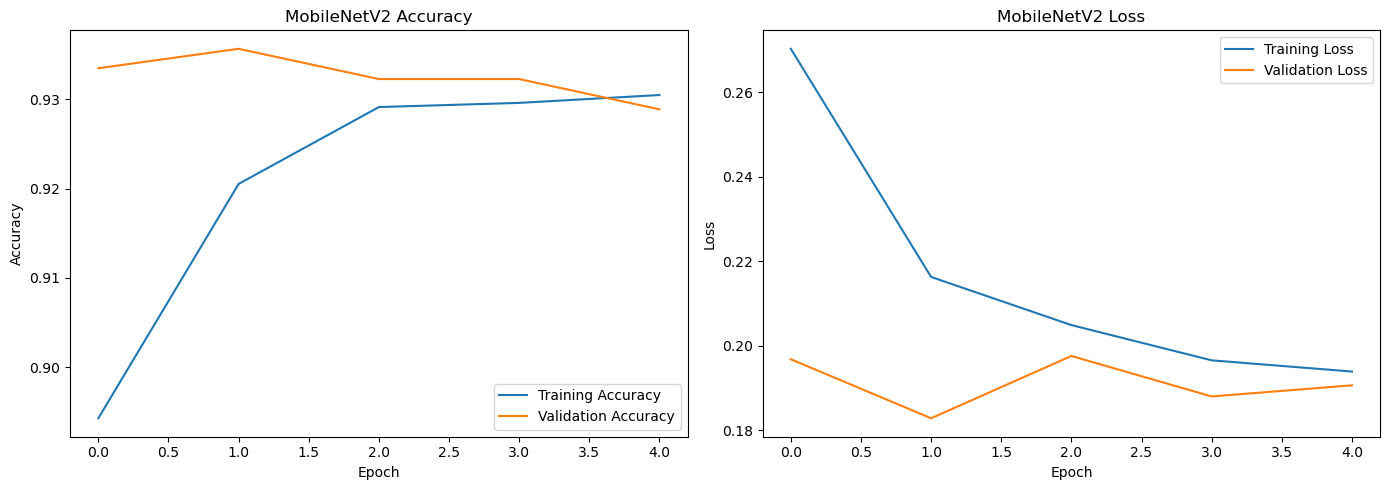

130/130 ━━━━━━━━━━━━━━━━━━━━ 73s 557ms/step

MobileNetV2 PERFORMANCE

Accuracy      : 93.59%
Precision     : 95.74%
Recall        : 91.24%
F1 Score      : 93.44%

Training Time : 2142.44 seconds
Testing Time  : 73.42 seconds
              precision    recall  f1-score   support

  Uninfected       0.92      0.96      0.94      2067
 Parasitized       0.96      0.91      0.93      2067

    accuracy                           0.94      4134
   macro avg       0.94      0.94      0.94      4134
weighted avg       0.94      0.94      0.94      4134



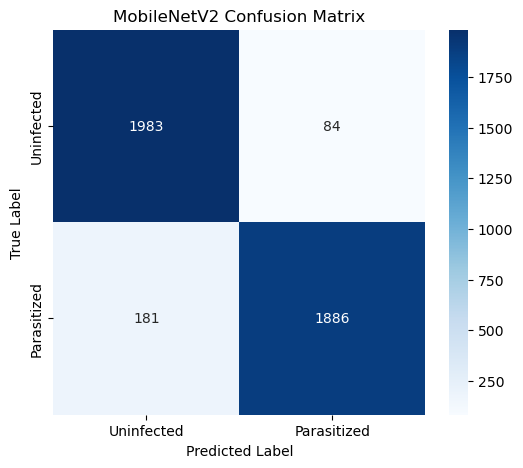

MobileNetV2 Model Saved Successfully!


In [19]:
# MobileNetV2
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

import tensorflow as tf

from tensorflow.keras.applications import MobileNetV2

from tensorflow.keras.models import Model

from tensorflow.keras.layers import (
    GlobalAveragePooling2D,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

# Load MobileNetV2 Base Model
base_model = MobileNetV2(

    weights="imagenet",

    include_top=False,

    input_shape=(224,224,3)

)

base_model.trainable = False

# Build MobileNetV2 Model

x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dense(

    512,

    activation="relu"

)(x)

x = Dropout(0.5)(x)

x = Dense(

    256,

    activation="relu"

)(x)

x = Dropout(0.3)(x)

output = Dense(

    1,

    activation="sigmoid"

)(x)

mobilenet_model = Model(

    inputs=base_model.input,

    outputs=output

)

# Display Model Summary
print("MobileNetV2 MODEL SUMMARY\n")

mobilenet_model.summary()

# Compile Model
mobilenet_model.compile(

    optimizer="adam",

    loss="binary_crossentropy",

    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]

)

# Callbacks
early_stop = EarlyStopping(

    monitor="val_loss",

    patience=5,

    restore_best_weights=True

)

checkpoint = ModelCheckpoint(

    "MobileNetV2_model.keras",

    monitor="val_accuracy",

    save_best_only=True,

    verbose=1

)

reduce_lr = ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.2,

    patience=3,

    verbose=1

)

# Train Model
print("Training MobileNetV2 Model...\n")

start_train = time.time()

mobilenet_history = mobilenet_model.fit(

    train_ds,

    validation_data=val_ds,

    epochs=5,

    callbacks=[

        early_stop,

        checkpoint,

        reduce_lr

    ]

)

end_train = time.time()

mobilenet_training_time = end_train - start_train

print(f"\nTraining Time : {mobilenet_training_time:.2f} seconds")

# Plot Accuracy and Loss
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)

plt.plot(

    mobilenet_history.history["accuracy"],

    label="Training Accuracy"

)

plt.plot(

    mobilenet_history.history["val_accuracy"],

    label="Validation Accuracy"

)

plt.title("MobileNetV2 Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.subplot(1,2,2)

plt.plot(

    mobilenet_history.history["loss"],

    label="Training Loss"

)

plt.plot(

    mobilenet_history.history["val_loss"],

    label="Validation Loss"

)

plt.title("MobileNetV2 Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.tight_layout()

plt.show()

# Evaluate Model
start_test = time.time()

predictions = mobilenet_model.predict(test_ds)

end_test = time.time()

mobilenet_testing_time = end_test - start_test

y_pred_mob = (

    predictions > 0.5

).astype(int).flatten()

y_true = np.concatenate([

    labels.numpy()

    for images, labels in test_ds

])

# Performance Metrics
accuracy_mob = accuracy_score(

    y_true,

    y_pred_mob

)

precision_mob = precision_score(

    y_true,

    y_pred_mob

)

recall_mob = recall_score(

    y_true,

    y_pred_mob

)

f1_mob = f1_score(

    y_true,

    y_pred_mob

)


print("\nMobileNetV2 PERFORMANCE\n")

print(f"Accuracy      : {accuracy_mob*100:.2f}%")

print(f"Precision     : {precision_mob*100:.2f}%")

print(f"Recall        : {recall_mob*100:.2f}%")

print(f"F1 Score      : {f1_mob*100:.2f}%")

print(f"\nTraining Time : {mobilenet_training_time:.2f} seconds")

print(f"Testing Time  : {mobilenet_testing_time:.2f} seconds")

# Classification Report
print(

    classification_report(

        y_true,

        y_pred_mob,

        target_names=[

            "Uninfected",

            "Parasitized"

        ]

    )

)

# Confusion Matrix
cm = confusion_matrix(

    y_true,

    y_pred_mob

)

plt.figure(figsize=(6,5))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues",

    xticklabels=[

        "Uninfected",

        "Parasitized"

    ],

    yticklabels=[

        "Uninfected",

        "Parasitized"

    ]

)

plt.xlabel("Predicted Label")

plt.ylabel("True Label")

plt.title("MobileNetV2 Confusion Matrix")

plt.show()

# Save Model
mobilenet_model.save(

    "MobileNetV2_model.keras"

)

print("MobileNetV2 Model Saved Successfully!")

# Store Results
mobilenet_results = {

    "Model": "MobileNetV2",

    "Accuracy": accuracy_mob,

    "Precision": precision_mob,

    "Recall": recall_mob,

    "F1 Score": f1_mob,

    "Training Time": mobilenet_training_time,

    "Testing Time": mobilenet_testing_time

}